In [13]:
#!pip install optuna

In [14]:
# 1. Importaciones
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import optuna
import warnings

from sklearn.base import clone
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
import time

from scipy.stats import f_oneway, friedmanchisquare
import matplotlib.pyplot as plt

import seaborn as sns
import gc
import tracemalloc
from joblib import Parallel, delayed


warnings.filterwarnings('ignore')

In [15]:
def encode_target(y):
    if isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
    return y.astype(int)

# 2. Cargar Datasets adecuados
def load_datasets():
    datasets = []

    from sklearn.datasets import fetch_openml
    from sklearn.datasets import load_breast_cancer

    # Dataset: Banknote Authentication (Seguridad bancaria)
    X, y = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False)
    datasets.append(("BanknoteAuth", X, y.astype(int)))

    # Dataset: Breast Cancer (WDBC)
    data = load_breast_cancer()
    datasets.append(("BreastCancer", data.data, data.target))

    # Dataset: Heart Disease Cleveland (UCI)
    X, y = fetch_openml(data_id=53, return_X_y=True, as_frame=True)
    X = X.select_dtypes(include='number').to_numpy()
    y = encode_target(y)
    datasets.append(("HeartDisease", X, y))

    # Dataset: Ionosphere (Radar UCI)
    X_df, y = fetch_openml(name="ionosphere", version=1, return_X_y=True, as_frame=True)
    y = encode_target(y)
    datasets.append(("Ionosphere", X_df.values.astype(float), y))

    # Dataset: KC2 Software Defect Prediction
    X, y = fetch_openml(name="kc2", version=1, return_X_y=True, as_frame=False)
    datasets.append(("KC2", X, y))

    # Dataset: QSAR Biodegradation (Biodegradabilidad química)
    X, y = fetch_openml(name="QSAR-Biodeg", version=1, return_X_y=True, as_frame=False)
    datasets.append(("QSARBiodeg", X, y.astype(int)))

    # Dataset: SpamBase (UCI)
    X, y = fetch_openml(name="spambase", version=1, return_X_y=True, as_frame=False)
    datasets.append(("SpamBase", X, y.astype(int)))

    return datasets

In [16]:
# 3. Definir funciones de entrenamiento para los métodos

def train_base(X_train, y_train, X_val=None, y_val=None):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0

def train_ccp(X_train, y_train, X_val, y_val):
    t_start = time.perf_counter()
    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_score = 0
    best_alpha = 0
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = alpha
    train_time_ms = (time.perf_counter() - t_start) * 1000
    t_prune = time.perf_counter()
    final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    final_model.fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return final_model, train_time_ms, prune_time_ms

def train_ccp_modified_optimized(X_train, y_train, X_val, y_val, seed=42, n_trials=60):
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, depth_penalty, feature_penalty_weight):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + depth_penalty * c["depth"]
                + feature_penalty_weight * (c["n_used"] / n_total_features))

    def eval_alpha(c, depth_penalty, feature_penalty_weight):
        modified_alpha = compute_modified_alpha(c, depth_penalty, feature_penalty_weight)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    def objective(trial):
        depth_penalty = trial.suggest_float("depth_penalty", 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float("feature_penalty_weight", 0.01, 0.2)
        scores = Parallel(n_jobs=1)(
            delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
            for c in cached_trees
        )
        return max(scores)

    t_start = time.perf_counter()
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=4)
    best_params = study.best_params
    depth_penalty = best_params["depth_penalty"]
    feature_penalty_weight = best_params["feature_penalty_weight"]
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=1)(
        delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
        for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, depth_penalty, feature_penalty_weight)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms

def train_ccp_ablation(X_train, y_train, X_val, y_val, depth_penalty='tune', feature_penalty_weight='tune', seed=42, n_trials=60):
    """
    Ablation wrapper for SR-CCP. Pass 0 to fix a penalty, 'tune' to let Optuna search.
    """
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, dp, fpw):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + dp * c["depth"]
                + fpw * (c["n_used"] / n_total_features))

    def eval_alpha(c, dp, fpw):
        modified_alpha = compute_modified_alpha(c, dp, fpw)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    t_start = time.perf_counter()

    tune_depth = depth_penalty == 'tune'
    tune_feat = feature_penalty_weight == 'tune'

    if tune_depth or tune_feat:
        def objective(trial):
            dp = trial.suggest_float("depth_penalty", 0.0001, 0.01) if tune_depth else depth_penalty
            fpw = trial.suggest_float("feature_penalty_weight", 0.01, 0.2) if tune_feat else feature_penalty_weight
            scores = Parallel(n_jobs=1)(
                delayed(eval_alpha)(c, dp, fpw) for c in cached_trees
            )
            return max(scores)

        sampler = optuna.samplers.TPESampler(seed=seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=4)
        best_params = study.best_params
        final_dp = best_params.get("depth_penalty", depth_penalty) if tune_depth else depth_penalty
        final_fpw = best_params.get("feature_penalty_weight", feature_penalty_weight) if tune_feat else feature_penalty_weight
    else:
        final_dp = depth_penalty
        final_fpw = feature_penalty_weight

    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=1)(
        delayed(eval_alpha)(c, final_dp, final_fpw) for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, final_dp, final_fpw)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms


def train_rep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol y aplica Reduced Error Pruning con poda lógica.
    Retorna un modelo DecisionTreeClassifier podado.
    """
    t_start = time.perf_counter()
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree_pruned = deepcopy(tree)
    classes_in_tree = tree_pruned.classes_

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left = tree_pruned.tree_.children_left[node_id]
        right = tree_pruned.tree_.children_right[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            tree_pruned.tree_.children_left[node_id],
            tree_pruned.tree_.children_right[node_id],
            tree_pruned.tree_.feature[node_id],
            tree_pruned.tree_.threshold[node_id],
            tree_pruned.tree_.value[node_id].copy()
        )
        tree_pruned.tree_.children_left[node_id] = -1
        tree_pruned.tree_.children_right[node_id] = -1
        tree_pruned.tree_.feature[node_id] = -2
        tree_pruned.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree_pruned, X_val, node_id)
        if np.sum(mask) == 0:
            revert_pruning(node_id, backup)
            return
        y_node = y_val[mask]
        unique_classes, counts = np.unique(y_node, return_counts=True)
        majority_label = unique_classes[np.argmax(counts)]
        majority_index = np.where(classes_in_tree == majority_label)[0][0]
        new_value = np.zeros((1, len(classes_in_tree)))
        new_value[0, majority_index] = counts.max()
        tree_pruned.tree_.value[node_id] = new_value
        acc_before = np.mean(tree.predict(X_val) == y_val)
        acc_after = np.mean(tree_pruned.predict(X_val) == y_val)
        if acc_after < acc_before:
            revert_pruning(node_id, backup)

    def revert_pruning(node_id, backup):
        (cl, cr, f, t, v) = backup
        tree_pruned.tree_.children_left[node_id] = cl
        tree_pruned.tree_.children_right[node_id] = cr
        tree_pruned.tree_.feature[node_id] = f
        tree_pruned.tree_.threshold[node_id] = t
        tree_pruned.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree_pruned, train_time_ms, prune_time_ms

def train_depth_pruning(X_train, y_train, X_val=None, y_val=None, max_depth=5):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0
from sklearn.tree import DecisionTreeClassifier
from copy import deepcopy
import numpy as np

def train_mep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol de decisión completo y aplica Minimum Error Pruning (MEP),
    podando nodos cuando el error estimado como hoja es menor que como subárbol.

    Retorna un árbol podado (DecisionTreeClassifier).
    """
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree = deepcopy(clf)
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    n_nodes = tree.tree_.node_count
    classes = tree.classes_
    n_classes = len(classes)

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left, right = cl[node_id], cr[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            cl[node_id], cr[node_id],
            tree.tree_.feature[node_id],
            tree.tree_.threshold[node_id],
            tree.tree_.value[node_id].copy()
        )
        cl[node_id] = cr[node_id] = -1
        tree.tree_.feature[node_id] = -2
        tree.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree, X_val, node_id)
        if np.sum(mask) == 0:
            revert(node_id, backup)
            return
        y_node = y_val[mask]
        values = np.zeros((1, n_classes))
        for c in np.unique(y_node):
            if c in classes:
                idx = np.where(classes == c)[0][0]
                values[0, idx] = np.sum(y_node == c)
        tree.tree_.value[node_id] = values
        y_true = y_val[mask]
        y_pred_full = clf.predict(X_val[mask])
        y_pred_pruned = tree.predict(X_val[mask])
        err_before = np.sum(y_pred_full != y_true)
        err_after = np.sum(y_pred_pruned != y_true)
        if err_after > err_before:
            revert(node_id, backup)

    def revert(node_id, backup):
        cl[node_id], cr[node_id], f, t, v = backup
        tree.tree_.feature[node_id] = f
        tree.tree_.threshold[node_id] = t
        tree.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree, train_time_ms, prune_time_ms

def count_reachable_nodes_and_leaves(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def count(node):
        if node == -1:
            return (0, 0)
        if cl[node] == -1 and cr[node] == -1:
            return (1, 1)
        ln, ll = count(cl[node])
        rn, rl = count(cr[node])
        return (1 + ln + rn, ll + rl)
    return count(0)

def count_real_depth(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def depth(node):
        if node == -1:
            return 0
        if cl[node] == -1 and cr[node] == -1:
            return 1
        return 1 + max(depth(cl[node]), depth(cr[node]))
    return depth(0)

def count_used_features(model):
    """Returns the number of unique features used in decision splits."""
    used_features = model.tree_.feature
    return len(set(used_features[used_features >= 0]))

def evaluate(model, X_test, y_test, n_runs=10000, discard_first=True, use_median=True):
    """
    Evalúa el modelo con múltiples ejecuciones para reducir la varianza en tiempo de inferencia.
    Also measures model memory usage.
    """
    # Measure memory usage by serializing the model
    import io, pickle
    buffer = io.BytesIO()
    pickle.dump(model, buffer)
    memory_usage_kb = buffer.tell() / 1024

    times = []
    y_pred = None

    gc.disable()

    for _ in range(n_runs + 1 if discard_first else n_runs):
        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        elapsed = time.perf_counter() - start_time
        times.append(elapsed)

    gc.enable()

    if discard_first:
        times = times[1:]

    times_ms = np.array(times) * 1000
    inference_std = times_ms.std()

    if use_median:
        inference_time = np.median(times_ms)
    else:
        inference_time = times_ms.mean()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    depth = count_real_depth(model)
    n_nodes, n_leaves = count_reachable_nodes_and_leaves(model)
    n_features_used = count_used_features(model)

    return accuracy, f1, balanced_acc, depth, n_nodes, n_leaves, inference_time, inference_std, n_features_used, memory_usage_kb

from sklearn.feature_selection import SelectKBest, f_classif

def cross_validate_models(X, y, model_fns, k=5):
    """
    cross_validate_models: Validación cruzada con entrenamiento y evaluación por modelo.
    Retorna:
      means    : dict modelo -> media de cada métrica (10 valores)
      stds     : dict modelo -> desviación estándar de cada métrica
      train_times : dict modelo -> media de tiempo de entrenamiento (ms)
      train_stds  : dict modelo -> desviación estándar del tiempo de entrenamiento (ms)
      prune_times : dict modelo -> media de tiempo de poda (ms)
      prune_stds  : dict modelo -> desviación estándar del tiempo de poda (ms)
      peak_memory_mean : dict modelo -> media de memoria pico (KB)
      peak_memory_std  : dict modelo -> desviación estándar de memoria pico (KB)
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    results = {name: [] for name in model_fns}
    train_times = {name: [] for name in model_fns}
    prune_times = {name: [] for name in model_fns}
    peak_memories = {name: [] for name in model_fns}

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
        )

        print(f"\n--- Fold {fold_idx+1}/{k} ---")
        print(f"  Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

        for name, fn in model_fns.items():
            print(f"  Training {name}...")
            tracemalloc.start()
            model, t_ms, p_ms = fn(X_train, y_train, X_val, y_val)
            _, peak_bytes = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            peak_memory_kb = peak_bytes / 1024
            metrics = evaluate(model, X_test, y_test)
            results[name].append(metrics)
            train_times[name].append(t_ms)
            prune_times[name].append(p_ms)
            peak_memories[name].append(peak_memory_kb)
            print(f"    => {metrics[:5]}")

    means = {name: np.mean(vals, axis=0) for name, vals in results.items()}
    stds  = {name: np.std(vals, axis=0)  for name, vals in results.items()}
    train_time_mean = {name: np.mean(times) for name, times in train_times.items()}
    train_time_std  = {name: np.std(times)  for name, times in train_times.items()}
    prune_time_mean = {name: np.mean(times) for name, times in prune_times.items()}
    prune_time_std  = {name: np.std(times)  for name, times in prune_times.items()}
    peak_memory_mean = {name: np.mean(mems) for name, mems in peak_memories.items()}
    peak_memory_std  = {name: np.std(mems)  for name, mems in peak_memories.items()}

    return means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std

# ======================= EVALUACIÓN POR DATASET ===========================
datasets = load_datasets()
results = []

for name, X, y in datasets:
    print(f"Procesando {name}...")

    model_fns = {
        "Base":             train_base,
        "CCP":              train_ccp,
        "CCP_Modified":     train_ccp_modified_optimized,
        "REP":              train_rep,
        "MEP":              train_mep,
        "DepthPruning":     train_depth_pruning
    }

    means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std = cross_validate_models(X, y, model_fns, k=5)

    for method in model_fns:
        m = means[method]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        results.append([
            name, method, acc, f1, balanced_acc,
            depth, nodes, leaves,
            inference_time, inference_std, n_features_used,
            train_time_mean[method], prune_time_mean[method], memory_kb, peak_memory_mean[method]
        ])


Procesando BanknoteAuth...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP_Modified...


[I 2026-07-02 06:53:13,058] A new study created in memory with name: no-name-702de30c-db92-4e8b-88cd-e157ec93687d
[I 2026-07-02 06:53:13,980] Trial 0 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.0051366797414524705, 'feature_penalty_weight': 0.10558461207163279}. Best is trial 0 with value: 0.8636363636363636.
[I 2026-07-02 06:53:14,012] Trial 1 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.007132540571285951, 'feature_penalty_weight': 0.0892967324379102}. Best is trial 0 with value: 0.8636363636363636.
[I 2026-07-02 06:53:14,108] Trial 2 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.007066534045546333, 'feature_penalty_weight': 0.048155736407543906}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-02 06:53:14,214] Trial 3 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.001214003448489086, 'feature_penalty_weight': 0.085470334778267}. Best is trial 2 with va

    => (0.8909090909090909, 0.8876266753841124, 0.8828618879245688, 3, 5)
  Training REP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training MEP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training DepthPruning...
    => (0.9672727272727273, 0.9668785547005687, 0.9672666880960035, 6, 33)

--- Fold 2/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP...
    => (0.9890909090909091, 0.9889595182335229, 0.9893656916318441, 8, 45)
  Training CCP_Modified...


[I 2026-07-02 06:53:38,982] A new study created in memory with name: no-name-2d605bb2-6b72-437f-bf23-824ba28b2876
[I 2026-07-02 06:53:39,908] Trial 2 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.0067309308602269986, 'feature_penalty_weight': 0.05731043511271811}. Best is trial 2 with value: 0.9045454545454545.
[I 2026-07-02 06:53:39,964] Trial 1 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.00663730042568512, 'feature_penalty_weight': 0.15065172093394755}. Best is trial 2 with value: 0.9045454545454545.
[I 2026-07-02 06:53:40,006] Trial 3 finished with value: 0.9409090909090909 and parameters: {'depth_penalty': 0.0033475620499021906, 'feature_penalty_weight': 0.016520074309664897}. Best is trial 3 with value: 0.9409090909090909.
[I 2026-07-02 06:53:40,024] Trial 0 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.004411980719315924, 'feature_penalty_weight': 0.16753508035234096}. Best is trial 3 with

    => (0.9381818181818182, 0.9365576951783849, 0.9319886424515161, 6, 15)
  Training REP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training MEP...
    => (0.9854545454545455, 0.9852673309761063, 0.9852673309761063, 6, 25)
  Training DepthPruning...
    => (0.9781818181818182, 0.9779694509720145, 0.9795617700632165, 6, 37)

--- Fold 3/5 ---
  Train: 878, Validation: 220, Test: 274
  Training Base...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP...
    => (0.9781021897810219, 0.9779032258064516, 0.9794542709232097, 9, 47)
  Training CCP_Modified...


...

    => (0.8684782608695653, 0.8599521180166341, 0.8544420869375986, 4, 11)
  Training REP...
    => (0.8902173913043478, 0.8834945126316673, 0.8786320855033112, 7, 27)
  Training MEP...
    => (0.8967391304347826, 0.8905364091683898, 0.8859370595130347, 9, 35)
  Training DepthPruning...
    => (0.8956521739130435, 0.8894446697610143, 0.8850393934448121, 6, 51)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8945652173913043, 0.8892802596529277, 0.8883393730568923, 37, 419)
  Training CCP...
    => (0.9108695652173913, 0.9053588185408397, 0.900324758906117, 13, 63)
  Training CCP_Modified...


[I 2026-07-02 07:15:08,169] A new study created in memory with name: no-name-dd7e4a51-2656-4e81-95a9-8048b659948d
[I 2026-07-02 07:15:19,556] Trial 3 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.002726677143337227, 'feature_penalty_weight': 0.10596382945317247}. Best is trial 3 with value: 0.8887381275440976.
[I 2026-07-02 07:15:19,580] Trial 1 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.0074550284791673055, 'feature_penalty_weight': 0.06505869527602683}. Best is trial 3 with value: 0.8887381275440976.
[I 2026-07-02 07:15:19,605] Trial 2 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.007198440682569404, 'feature_penalty_weight': 0.07347742459904441}. Best is trial 3 with value: 0.8887381275440976.
[I 2026-07-02 07:15:19,626] Trial 0 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.009680120139297355, 'feature_penalty_weight': 0.074492015690608}. Best is trial 3 with va

    => (0.9032608695652173, 0.8966306489873263, 0.8896859343749381, 6, 19)
  Training REP...
    => (0.9010869565217391, 0.8931323629465955, 0.8830422384601675, 6, 21)
  Training MEP...
    => (0.9, 0.8921640574037835, 0.8826313392344403, 13, 47)
  Training DepthPruning...
    => (0.9043478260869565, 0.8986576139475964, 0.8944632566981525, 6, 39)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training Base...
    => (0.8978260869565218, 0.8927579365079366, 0.8919978613437889, 32, 449)
  Training CCP...
    => (0.8956521739130435, 0.8901443348209621, 0.8882651141606764, 11, 95)
  Training CCP_Modified...


[I 2026-07-02 07:18:45,341] A new study created in memory with name: no-name-e70d2de8-22e9-44a5-b236-a1efc43a6e45
[I 2026-07-02 07:18:59,583] Trial 0 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.00526279389892131, 'feature_penalty_weight': 0.04508633970986033}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-02 07:18:59,658] Trial 1 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.0018396326193186921, 'feature_penalty_weight': 0.09052667425291727}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-02 07:18:59,777] Trial 2 finished with value: 0.8113975576662144 and parameters: {'depth_penalty': 0.009437290534644057, 'feature_penalty_weight': 0.1466098168325696}. Best is trial 0 with value: 0.8385345997286295.
[I 2026-07-02 07:18:59,962] Trial 3 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.008110369170913035, 'feature_penalty_weight': 0.16617349343648724}. Best is trial 0 with va

    => (0.8826086956521739, 0.8750697828809391, 0.8697498960375453, 5, 15)
  Training REP...
    => (0.8945652173913043, 0.8890567210567211, 0.8873690568130062, 7, 27)
  Training MEP...
    => (0.9, 0.8950396825396825, 0.8942751341610725, 13, 49)
  Training DepthPruning...
    => (0.9032608695652173, 0.8973367487546375, 0.8925968831065962, 6, 53)



Dataset: BanknoteAuth (n=1372, d=4)
  SR-CCP (full)...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training SR-CCP (full)...


[I 2026-07-02 07:22:38,362] A new study created in memory with name: no-name-3c576ba7-cdc7-4959-9ea8-7dfc128fbeac
[I 2026-07-02 07:22:38,939] Trial 2 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.005162598252724187, 'feature_penalty_weight': 0.08246198367893316}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-02 07:22:38,984] Trial 1 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.004988085648614773, 'feature_penalty_weight': 0.11525004133780611}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-02 07:22:39,028] Trial 0 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.003778791310242501, 'feature_penalty_weight': 0.10025700038016404}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-02 07:22:39,044] Trial 3 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.004779100240195848, 'feature_penalty_weight': 0.09435990329937012}. Best is trial 2 with v

    => (0.9090909090909091, 0.9069197546743207, 0.9033536912032573, 4, 7)

--- Fold 2/5 ---
  Train: 877, Validation: 220, Test: 275
  Training SR-CCP (full)...


[I 2026-07-02 07:22:50,195] A new study created in memory with name: no-name-888f0183-e3e9-40ca-ab48-1b535690870b
[I 2026-07-02 07:22:50,780] Trial 3 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.0017051182606415498, 'feature_penalty_weight': 0.08854944195280283}. Best is trial 3 with value: 0.9045454545454545.
[I 2026-07-02 07:22:50,833] Trial 0 finished with value: 0.9045454545454545 and parameters: {'depth_penalty': 0.0008700906974257233, 'feature_penalty_weight': 0.04371100803377459}. Best is trial 3 with value: 0.9045454545454545.
[I 2026-07-02 07:22:50,906] Trial 2 finished with value: 0.8590909090909091 and parameters: {'depth_penalty': 0.0056890840199695395, 'feature_penalty_weight': 0.15663727105743608}. Best is trial 3 with value: 0.9045454545454545.
[I 2026-07-02 07:22:50,909] Trial 1 finished with value: 0.9409090909090909 and parameters: {'depth_penalty': 0.001213370883738668, 'feature_penalty_weight': 0.022599546230670016}. Best is trial 1 wi

    => (0.9381818181818182, 0.9365576951783849, 0.9319886424515161, 6, 15)

--- Fold 3/5 ---
  Train: 878, Validation: 220, Test: 274
  Training SR-CCP (full)...


...

    => (0.9173913043478261, 0.9135470916113972, 0.9135470916113972, 12, 67)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Feature...


[I 2026-07-02 08:37:45,469] A new study created in memory with name: no-name-240472d6-ea40-437e-8198-dd7b1cdcc075
[I 2026-07-02 08:37:57,691] Trial 1 finished with value: 0.9118046132971506 and parameters: {'depth_penalty': 0.0001743529945370443}. Best is trial 1 with value: 0.9118046132971506.
[I 2026-07-02 08:37:57,922] Trial 2 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.00816316928242153}. Best is trial 1 with value: 0.9118046132971506.
[I 2026-07-02 08:37:58,012] Trial 3 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.004934713060917474}. Best is trial 1 with value: 0.9118046132971506.
[I 2026-07-02 08:37:58,230] Trial 0 finished with value: 0.8887381275440976 and parameters: {'depth_penalty': 0.006103706303852725}. Best is trial 1 with value: 0.9118046132971506.
[I 2026-07-02 08:38:08,835] Trial 4 finished with value: 0.8602442333785617 and parameters: {'depth_penalty': 0.008985368807363154}. Best is trial 1 with value: 0

    => (0.9010869565217391, 0.8953728871809292, 0.8917750846551417, 9, 37)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Feature...


[I 2026-07-02 08:41:32,692] A new study created in memory with name: no-name-47541f7a-5317-4ea7-be48-7c0b6ee2c731
[I 2026-07-02 08:41:50,187] Trial 0 finished with value: 0.8656716417910447 and parameters: {'depth_penalty': 0.002444035915943722}. Best is trial 0 with value: 0.8656716417910447.
[I 2026-07-02 08:41:50,239] Trial 1 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.009219399692024132}. Best is trial 0 with value: 0.8656716417910447.
[I 2026-07-02 08:41:50,415] Trial 2 finished with value: 0.8385345997286295 and parameters: {'depth_penalty': 0.009618513698500433}. Best is trial 0 with value: 0.8656716417910447.
[I 2026-07-02 08:41:50,523] Trial 3 finished with value: 0.8656716417910447 and parameters: {'depth_penalty': 0.0024931909422447377}. Best is trial 0 with value: 0.8656716417910447.
[I 2026-07-02 08:42:06,102] Trial 4 finished with value: 0.9090909090909091 and parameters: {'depth_penalty': 0.0005476136258631526}. Best is trial 4 with value:

    => (0.908695652173913, 0.9039742340802004, 0.9024139091863206, 10, 47)
  No Penalties...

--- Fold 1/5 ---
  Train: 2944, Validation: 736, Test: 921
  Training No Penalties...
    => (0.9077090119435396, 0.9032368111718005, 0.9026555881394591, 14, 91)

--- Fold 2/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9163043478260869, 0.9113736705737817, 0.9068924927420112, 14, 107)

--- Fold 3/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9195652173913044, 0.9159817351598174, 0.9167816569481333, 13, 153)

--- Fold 4/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.9108695652173913, 0.9053588185408397, 0.900324758906117, 13, 63)

--- Fold 5/5 ---
  Train: 2944, Validation: 737, Test: 920
  Training No Penalties...
    => (0.8956521739130435, 0.8901443348209621, 0.8882651141606764, 11, 95)

ABLATION SUMMARY (mean across datasets)
               Accuracy   Depth    Nodes   Leaves 

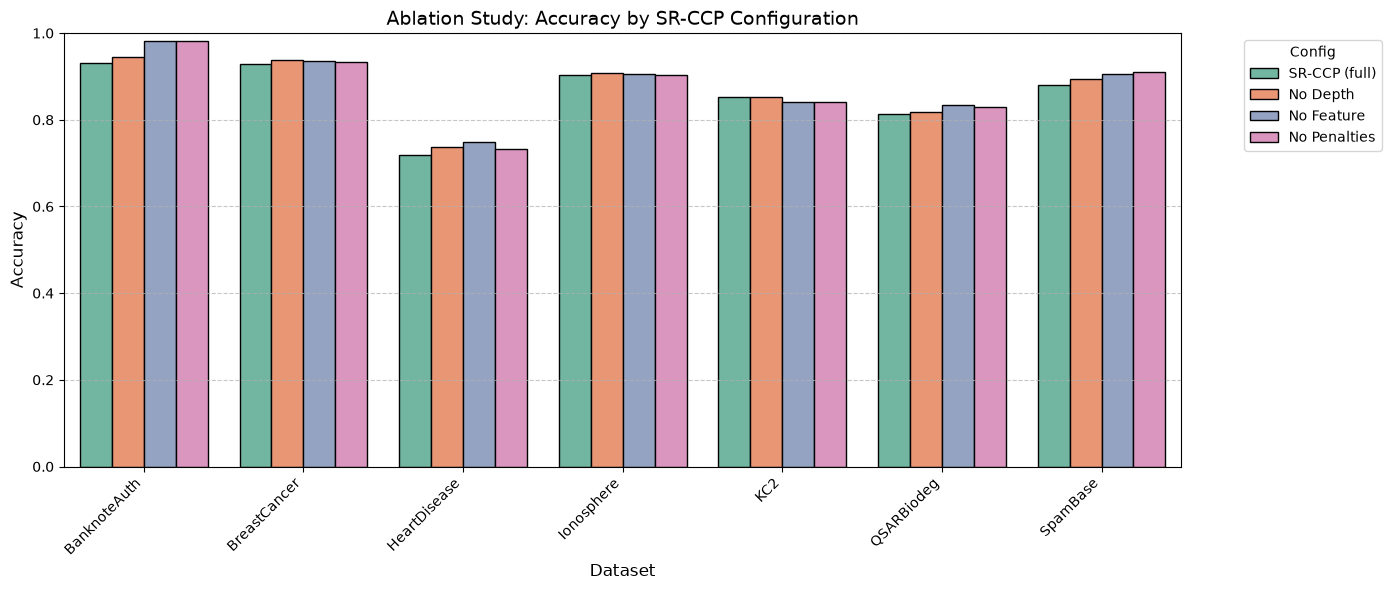

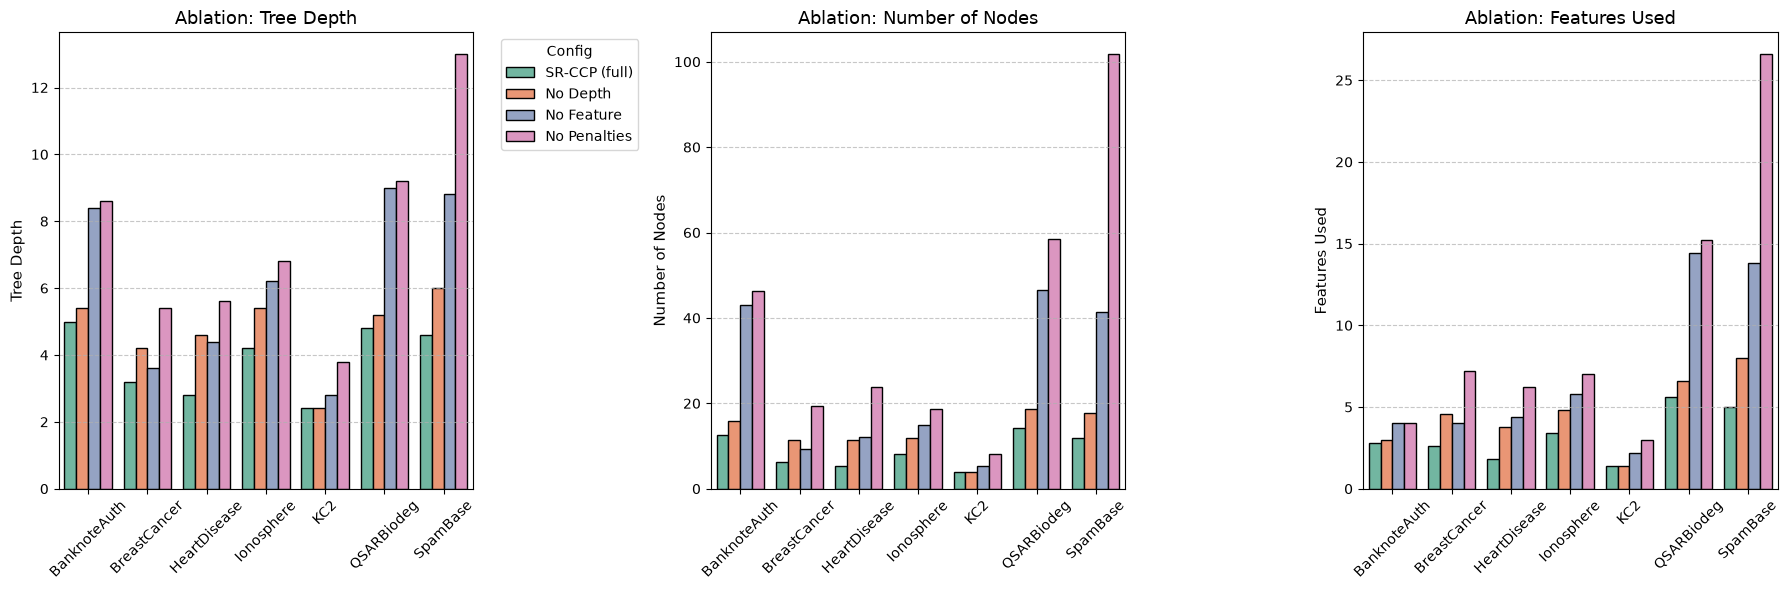


DELTA vs SR-CCP (full)

No Depth vs SR-CCP:
  Mean ΔAccuracy: 0.0091  Mean ΔFeatures: 1.4

No Feature vs SR-CCP:
  Mean ΔAccuracy: 0.0175  Mean ΔFeatures: 3.7

No Penalties vs SR-CCP:
  Mean ΔAccuracy: 0.0146  Mean ΔFeatures: 6.7


In [17]:
# ====================== ABLATION STUDY: SR-CCP COMPONENTS (Obs 14) ======================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configs = {
    'SR-CCP (full)':     {'depth_penalty': 'tune', 'feature_penalty_weight': 'tune'},
    'No Depth':          {'depth_penalty': 0,      'feature_penalty_weight': 'tune'},
    'No Feature':        {'depth_penalty': 'tune', 'feature_penalty_weight': 0},
    'No Penalties':      {'depth_penalty': 0,      'feature_penalty_weight': 0},
}

ablation_datasets = load_datasets()
ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    for cfg_name, cfg_params in configs.items():
        print(f"  {cfg_name}...")
        model_fns_abl = {
            cfg_name: lambda X_tr, y_tr, X_v, y_v, dp=cfg_params['depth_penalty'], fpw=cfg_params['feature_penalty_weight']: \
                train_ccp_ablation(X_tr, y_tr, X_v, y_v, depth_penalty=dp, feature_penalty_weight=fpw)
        }
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=5)
        m = means[cfg_name]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        ablation_results.append({
            'Dataset': ds_name, 'Config': cfg_name,
            'Accuracy': acc, 'F1': f1, 'Balanced_Acc': balanced_acc,
            'Depth': depth, 'Nodes': nodes, 'Leaves': leaves,
            'n_Features': n_features_used
        })

ablation_df = pd.DataFrame(ablation_results)

# --- Summary table ---
print("\n" + "="*80)
ablation_df.to_csv('ablation/ablation_results.csv', index=False)
print("ABLATION SUMMARY (mean across datasets)")
print("="*80)
summary = ablation_df.groupby('Config')[['Accuracy', 'Depth', 'Nodes', 'Leaves', 'n_Features']].mean()
print(summary.round(4))

# --- Chart 1: Accuracy per config per dataset ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=ablation_df, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy by SR-CCP Configuration', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation/ablation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Tree complexity (Depth, Nodes, n_Features) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes, ['Depth', 'Nodes', 'n_Features'], ['Tree Depth', 'Number of Nodes', 'Features Used']):
    sns.barplot(data=ablation_df, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'Ablation: {title}', fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0]:
        ax.get_legend().remove()
axes[0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation/ablation_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Delta from full SR-CCP ---
print("\n" + "="*80)
print("DELTA vs SR-CCP (full)")
print("="*80)
full = ablation_df[ablation_df['Config'] == 'SR-CCP (full)'].set_index('Dataset')
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial = ablation_df[ablation_df['Config'] == cfg].set_index('Dataset')
    delta_acc = partial['Accuracy'] - full['Accuracy']
    delta_feat = partial['n_Features'] - full['n_Features']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc.mean():.4f}  Mean ΔFeatures: {delta_feat.mean():.1f}")


In [18]:
"""
# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================
from functools import partial

def train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):
    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,
                                         seed=42, n_trials=n_trials)

ablation_datasets = load_datasets()
trials_list = [5, 10, 15, 20, 30, 60]
all_ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    # Benchmark CCP estandar como referencia
    model_fns_ccp = {"CCP": train_ccp}
    t_ccp = time.perf_counter()
    cross_validate_models(X, y, model_fns_ccp, k=3)
    ccp_time = (time.perf_counter() - t_ccp) * 1000

    for n_t in trials_list:
        print(f"  n_trials={n_t}...")
        fn = partial(train_ccp_modified_n, n_trials=n_t)
        model_fns_abl = {
            "CCP": train_ccp,
            f"CCP_Mod({n_t})": fn,
        }
        t0 = time.perf_counter()
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=3)
        total_ms = (time.perf_counter() - t0) * 1000

        m = means[f"CCP_Mod({n_t})"]
        m_ccp = means["CCP"]
        all_ablation_results.append({
            "dataset": ds_name,
            "n_trials": n_t,
            "accuracy": m[0],
            "f1": m[1],
            "balanced_acc": m[2],
            "total_time_ms": total_ms,
            "ccp_accuracy": m_ccp[0],
            "ccp_time_ms": ccp_time,
            "delta_acc": m[0] - m_ccp[0],
        })
        print(f"    Acc={m[0]:.4f}, CCP_Acc={m_ccp[0]:.4f}, dAcc={m[0]-m_ccp[0]:+.4f}, Time={total_ms:.0f}ms")

# =================== TABLA CONSOLIDADA ===================
print("\n" + "="*90)
print("ABLATION TABLE: n_trials vs Accuracy vs Time (ALL DATASETS)")
print("="*90)
print(f"{'Dataset':>16} {'n_trials':>8} {'Accuracy':>10} {'CCP_Acc':>10} {'dAcc':>8} {'Time(ms)':>10} {'CCP_Time':>10} {'Factor':>8}")
print("-"*90)
for r in all_ablation_results:
    factor = r["total_time_ms"] / r["ccp_time_ms"] if r["ccp_time_ms"] > 0 else 0
    print(f"{r['dataset']:>16} {r['n_trials']:>8} {r['accuracy']:>10.4f} {r['ccp_accuracy']:>10.4f} {r['delta_acc']:>+8.4f} {r['total_time_ms']:>10.0f} {r['ccp_time_ms']:>10.0f} {factor:>7.1f}x")

# =================== RESUMEN POR n_trials ===================
print("\n" + "="*70)
print("PROMEDIO POR n_trials (todos los datasets)")
print("="*70)
print(f"{'n_trials':>8} {'Avg_Acc':>10} {'Avg_dAcc':>10} {'Avg_Time':>10} {'Avg_Factor':>12}")
print("-"*55)
for n_t in trials_list:
    subset = [r for r in all_ablation_results if r["n_trials"] == n_t]
    avg_acc = np.mean([r["accuracy"] for r in subset])
    avg_dacc = np.mean([r["delta_acc"] for r in subset])
    avg_time = np.mean([r["total_time_ms"] for r in subset])
    avg_factor = np.mean([r["total_time_ms"] / r["ccp_time_ms"] for r in subset if r["ccp_time_ms"] > 0])
    print(f"{n_t:>8} {avg_acc:>10.4f} {avg_dacc:>+10.4f} {avg_time:>10.0f} {avg_factor:>11.1f}x")

# =================== GRAFICAS ===================
ablation_df = pd.DataFrame(all_ablation_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Grafica 1: Accuracy por dataset y n_trials
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[0].plot(subset["n_trials"], subset["accuracy"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[0].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[0].set_xlabel('n_trials')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por Dataset')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(True, alpha=0.3)

# Grafica 2: Delta Accuracy vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[1].plot(subset["n_trials"], subset["delta_acc"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('dAccuracy (CCP_Mod - CCP)')
axes[1].set_title('Delta Accuracy vs CCP Estandar')
axes[1].legend(fontsize=7, loc='best')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Factor de tiempo vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    factor = subset["total_time_ms"] / subset["ccp_time_ms"]
    axes[2].plot(subset["n_trials"], factor, 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[2].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[2].set_xlabel('n_trials')
axes[2].set_ylabel('Tiempo / Tiempo_CCP')
axes[2].set_title('Factor de Tiempo vs CCP')
axes[2].legend(fontsize=7, loc='best')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Efecto de n_trials en CCP_Modified (Todos los Datasets)', fontsize=14)
plt.tight_layout()
plt.show()
"""

'\n# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================\nfrom functools import partial\n\ndef train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):\n    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,\n                                         seed=42, n_trials=n_trials)\n\nablation_datasets = load_datasets()\ntrials_list = [5, 10, 15, 20, 30, 60]\nall_ablation_results = []\n\nfor ds_name, X, y in ablation_datasets:\n    print(f"\n{\'=\'*60}")\n    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")\n    print(f"{\'=\'*60}")\n\n    # Benchmark CCP estandar como referencia\n    model_fns_ccp = {"CCP": train_ccp}\n    t_ccp = time.perf_counter()\n    cross_validate_models(X, y, model_fns_ccp, k=3)\n    ccp_time = (time.perf_counter() - t_ccp) * 1000\n\n    for n_t in trials_list:\n        print(f"  n_trials={n_t}...")\n        fn = partial(train_ccp_modified_n, n_trials=n_t)\n        model_fns_abl = {\n       

         Dataset        Method  Accuracy  F1_Score  Balanced_Accuracy  Depth  \
0   BanknoteAuth          Base  0.981046  0.980822           0.981132    8.6   
1   BanknoteAuth           CCP  0.981776  0.981564           0.981952    8.6   
2   BanknoteAuth  CCP_Modified  0.905964  0.904207           0.902066    3.8   
3   BanknoteAuth           REP  0.964279  0.963761           0.963102    6.6   
4   BanknoteAuth           MEP  0.964279  0.963761           0.963102    6.6   
5   BanknoteAuth  DepthPruning  0.973033  0.972702           0.972789    6.0   
6   BreastCancer          Base  0.920928  0.914839           0.913092    7.4   
7   BreastCancer           CCP  0.933209  0.928497           0.927645    5.4   
8   BreastCancer  CCP_Modified  0.931501  0.926605           0.925430    3.6   
9   BreastCancer           REP  0.929747  0.924993           0.924883    4.4   
10  BreastCancer           MEP  0.931501  0.926798           0.926272    4.4   
11  BreastCancer  DepthPruning  0.927977

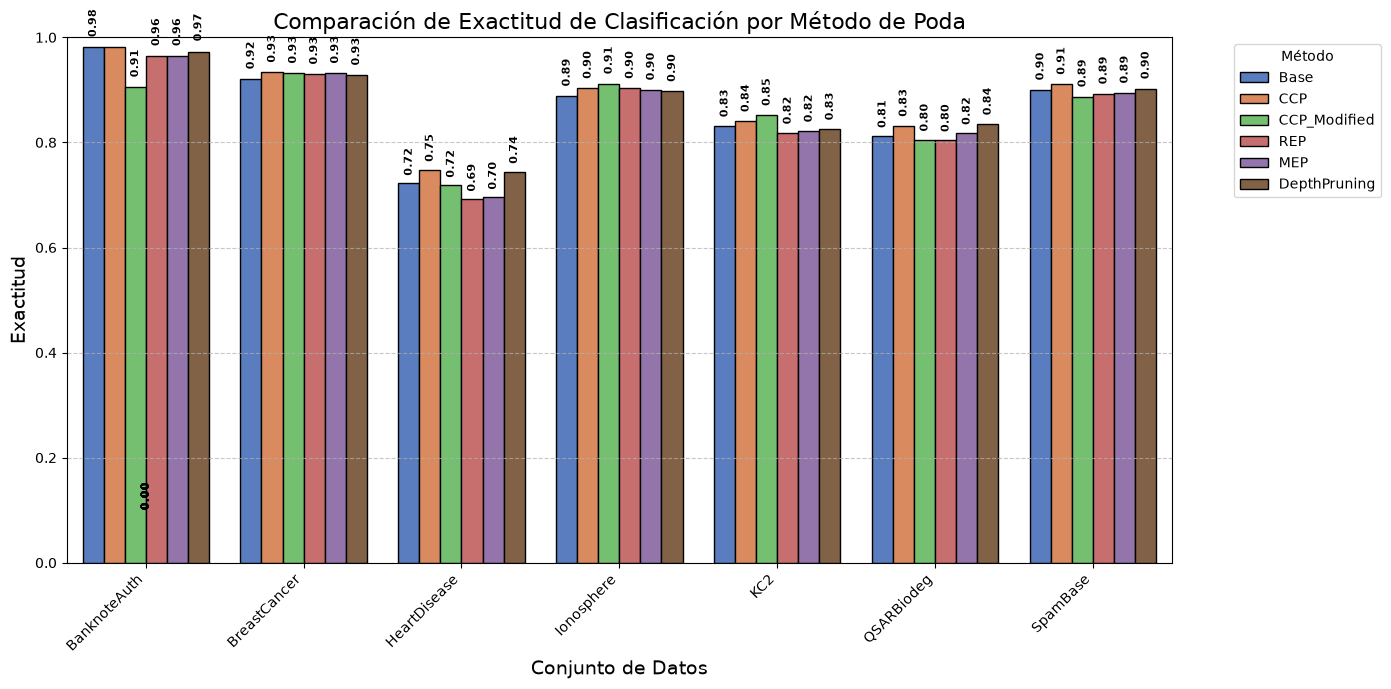

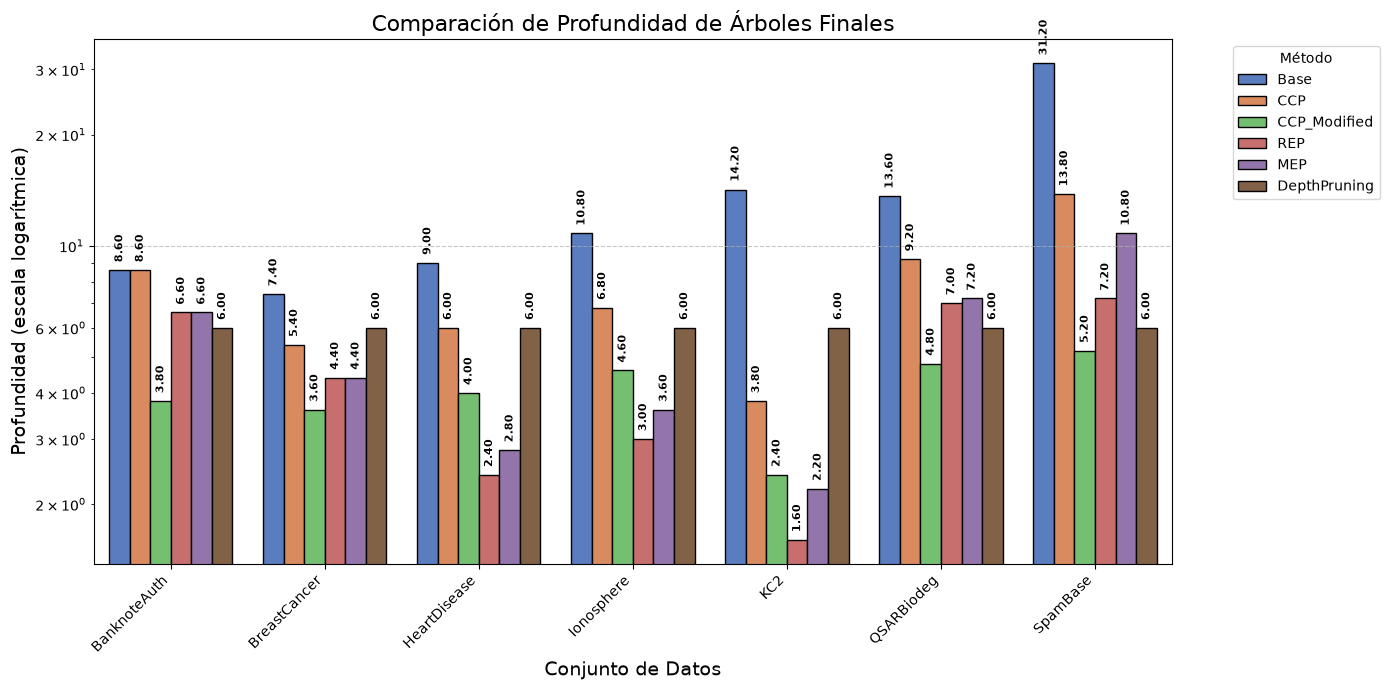

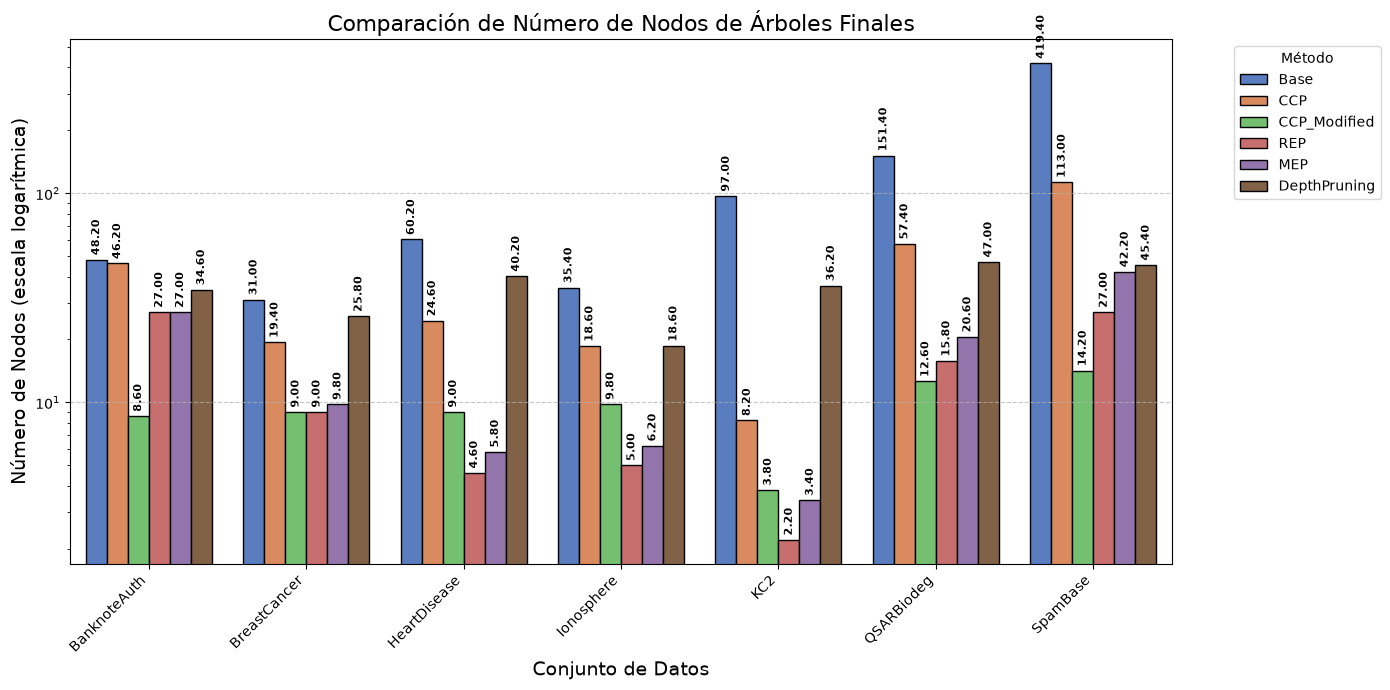

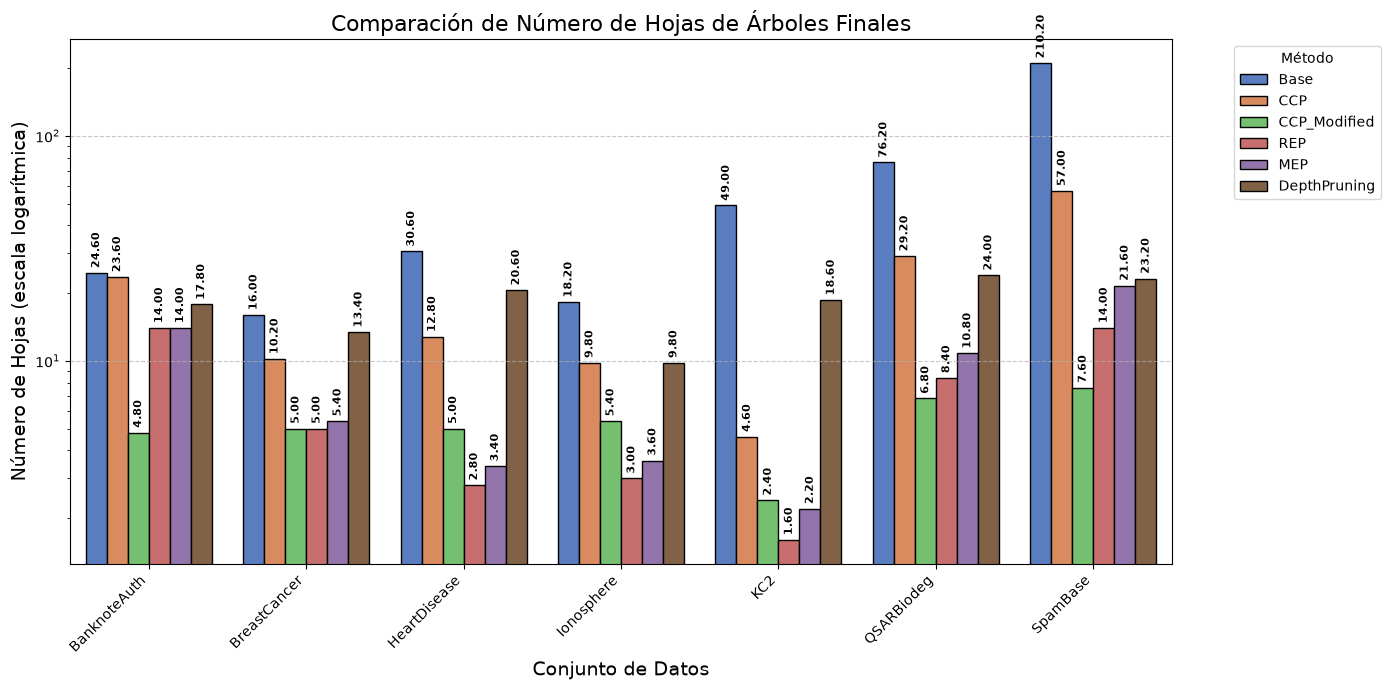

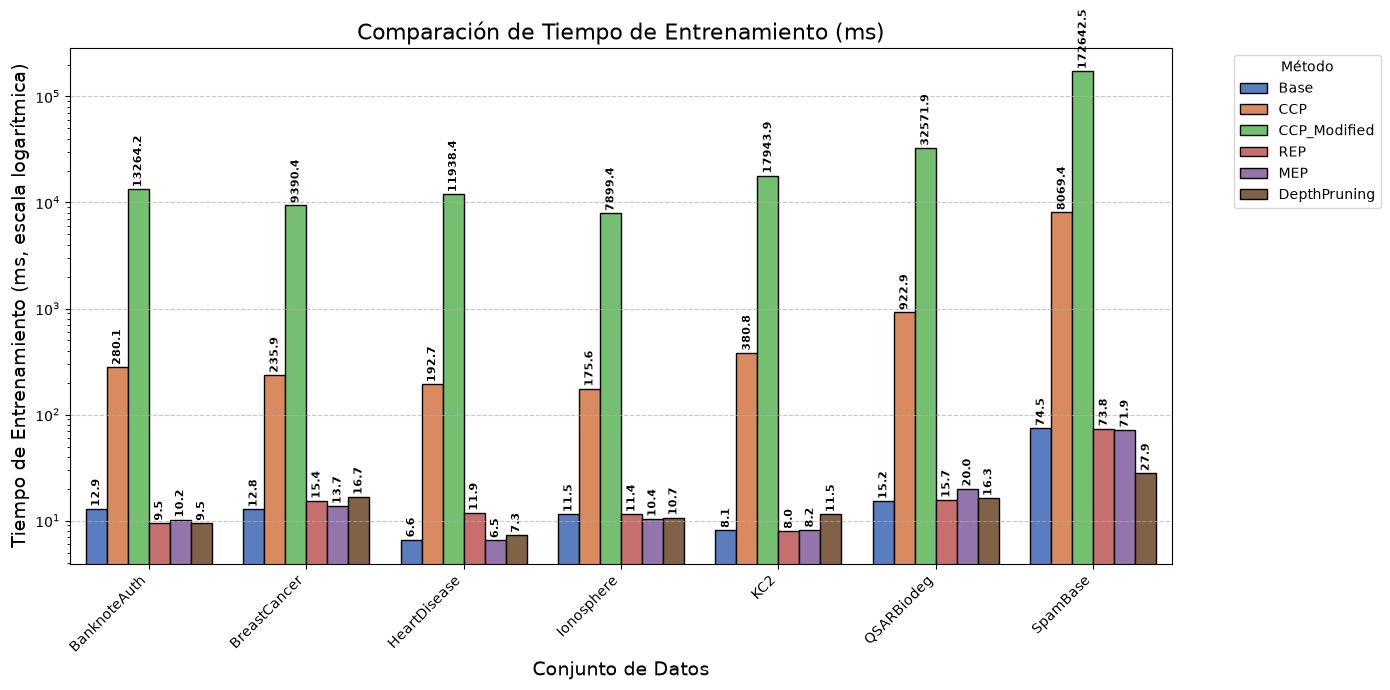

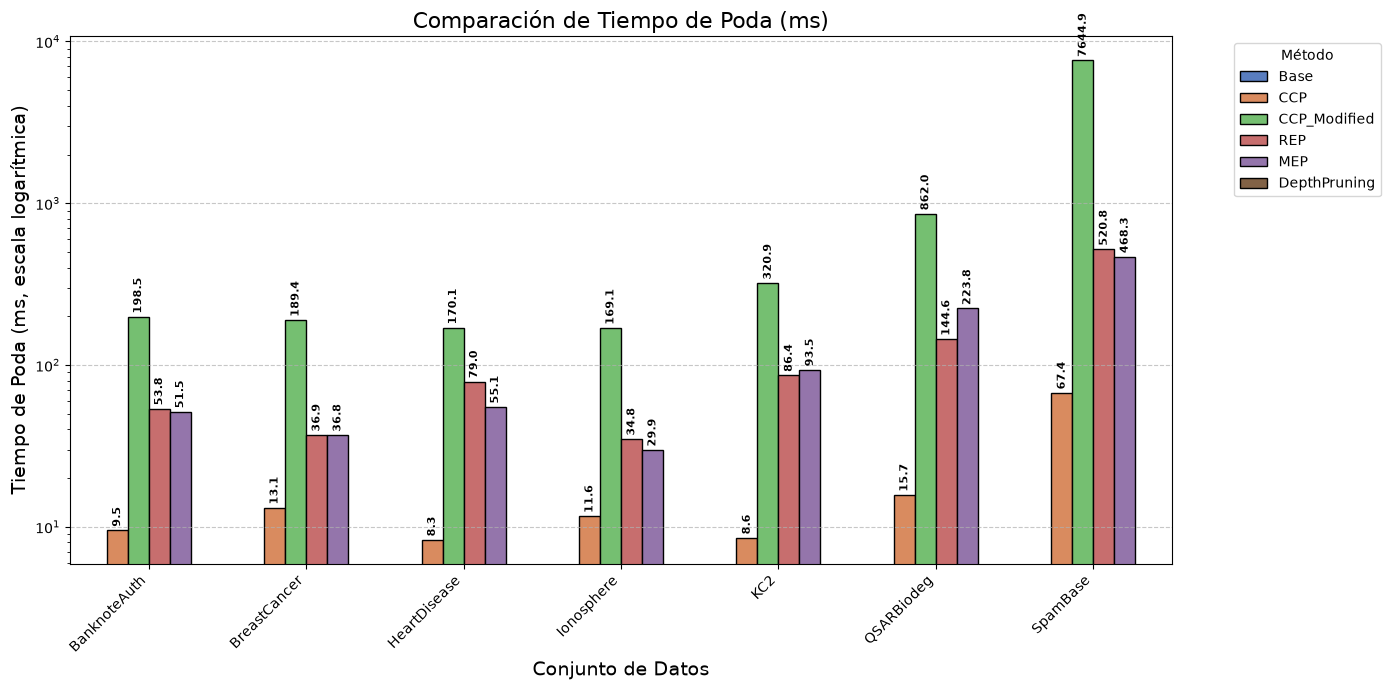

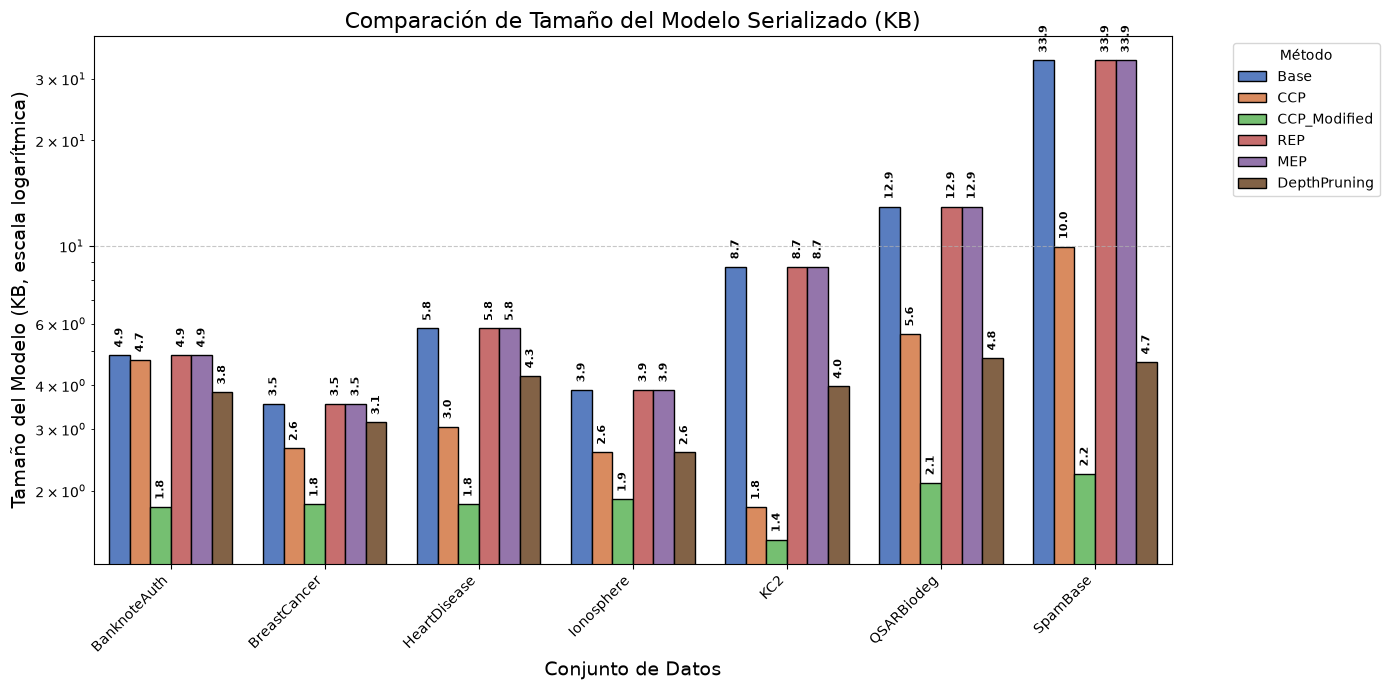

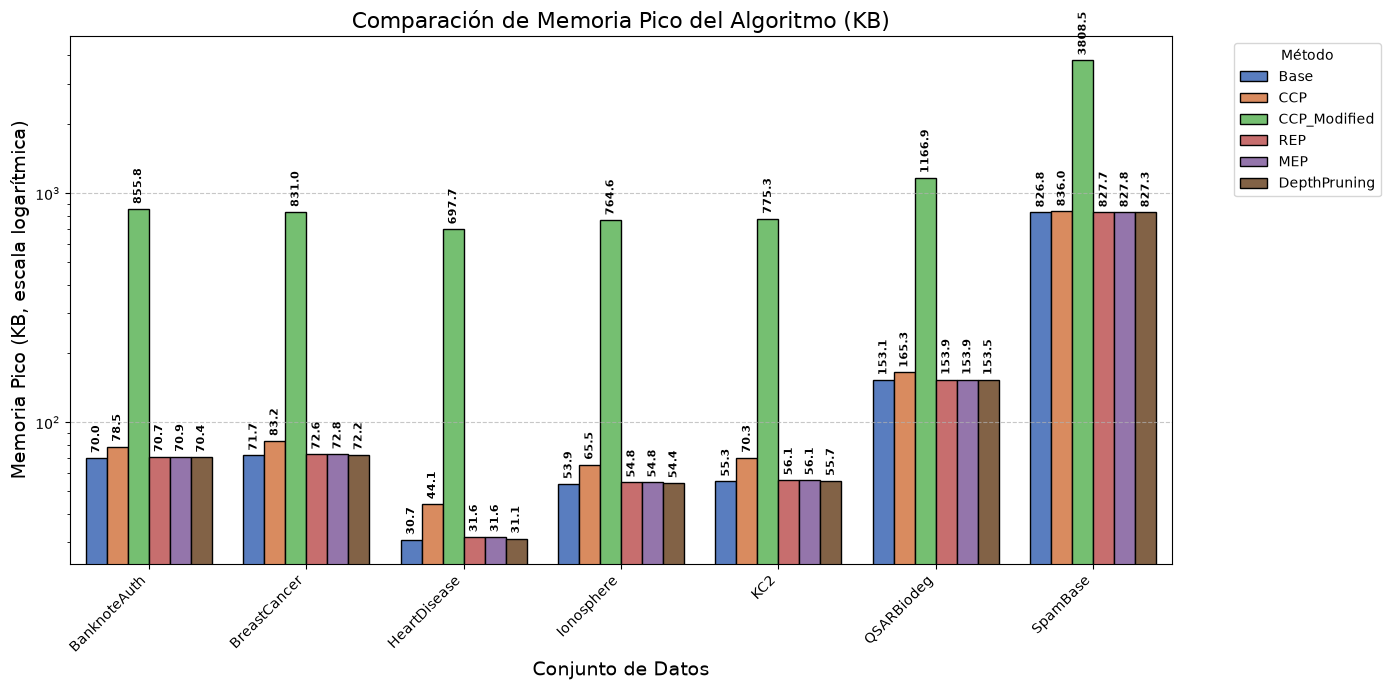

In [19]:
# ======================= RESULTADOS ===========================
results_df = pd.DataFrame(results, columns=[
    "Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy",
    "Depth", "Nodes", "Leaves", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features",
    "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"
])
print(results_df)

# ========== RESULTADOS ADICIONALES ==========
metrics_df = results_df[["Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]
accuracy_df = results_df[["Dataset", "Method", "Accuracy"]].rename(columns={"Accuracy": "Test Accuracy"})
details_df = results_df[["Dataset", "Method", "Depth", "Nodes", "Leaves"]]

print("\nMetricas de Prueba por Método:")
print(metrics_df.pivot(index="Dataset", columns="Method"))

print("\nDetalles de Árboles:")
print(details_df)

#========================== ANOVA ===================================

anova_result_acc = f_oneway(*[group['Accuracy'].values for name, group in metrics_df.groupby('Method')])
anova_result_f1 = f_oneway(*[group['F1_Score'].values for name, group in metrics_df.groupby('Method')])
anova_result_bal = f_oneway(*[group['Balanced_Accuracy'].values for name, group in metrics_df.groupby('Method')])

anova_result_depth = f_oneway(*[group['Depth'].values for name, group in details_df.groupby('Method')])
anova_result_nodes = f_oneway(*[group['Nodes'].values for name, group in details_df.groupby('Method')])
anova_result_leav = f_oneway(*[group['Leaves'].values for name, group in details_df.groupby('Method')])

anova_featu_nodes = f_oneway(*[group['n_Features'].values for name, group in metrics_df.groupby('Method')])
print(f'ANOVA Accuracy:     F={anova_result_acc.statistic:.2f}, p={anova_result_acc.pvalue:.4f}')
print(f'ANOVA F1:           F={anova_result_f1.statistic:.2f}, p={anova_result_f1.pvalue:.4f}')
print(f'ANOVA Balanced Acc: F={anova_result_bal.statistic:.2f}, p={anova_result_bal.pvalue:.4f}')
print(f'ANOVA Depth:        F={anova_result_depth.statistic:.2f}, p={anova_result_depth.pvalue:.4f}')
print(f'ANOVA Nodes:        F={anova_result_nodes.statistic:.2f}, p={anova_result_nodes.pvalue:.4f}')
print(f'ANOVA Leaves:       F={anova_result_leav.statistic:.2f}, p={anova_result_leav.pvalue:.4f}')
print(f'ANOVA Features:     F={anova_featu_nodes.statistic:.2f}, p={anova_featu_nodes.pvalue:.4f}')

# ========================== CSV FINAL UNIFICADO CON Δacc ==========================

# Obtener accuracy base por dataset
base_accuracies = results_df[results_df["Method"] == "Base"][["Dataset", "Accuracy"]].set_index("Dataset")

# Añadir columna Δacc
results_df["△acc"] = results_df.apply(
    lambda row: row["Accuracy"] - base_accuracies.loc[row["Dataset"], "Accuracy"]
    if row["Method"] != "Base" else 0.0,
    axis=1
)

# Reordenar y renombrar columnas
final_df = results_df[["Dataset", "Method", "Accuracy", "△acc", "F1_Score", "Balanced_Accuracy", "Leaves", "Nodes", "Depth", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]

# Guardar CSV final
final_df.to_csv("FINAL_RESULTADOS.csv", index=False)

# Mostrar resumen final
print("\nCSV Final Consolidado:")
print(final_df)


# Descargar en Colab si aplica
try:
    from google.colab import files
    files.download("FINAL_RESULTADOS.csv")
except:
    print("Descarga automática no disponible (no estás en Colab).")


#==============GRAFICAS INTERPRETABLES==================


# Función para anotar las barras
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, separadas adecuadamente."""
    for p in ax.patches:
        height = p.get_height()
        offset = height * 0.020 if height > 0 else 0.1
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height + offset),
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 1: Exactitud por Método ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=accuracy_df, x="Dataset", y="Test Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Exactitud de Clasificación por Método de Poda", fontsize=16)
plt.ylabel("Exactitud", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

#CARACTERÍSTICAS

# Función para anotar las barras correctamente, incluso las de valor 0
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, manejando valores cero correctamente."""
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            ax.annotate("0",
                        (p.get_x() + p.get_width() / 2., 0.2),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)
        else:
            offset = height * 0.05
            ax.annotate(fmt.format(height),
                        (p.get_x() + p.get_width() / 2., height + offset),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 2: Profundidad de Árboles (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Depth", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Profundidad de Árboles Finales", fontsize=16)
plt.ylabel("Profundidad (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 3: Cantidad de Nodos (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Nodes", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Nodos de Árboles Finales", fontsize=16)
plt.ylabel("Número de Nodos (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 4: Cantidad de Hojas (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Leaves", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Hojas de Árboles Finales", fontsize=16)
plt.ylabel("Número de Hojas (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 5: Tiempo de Entrenamiento (escala log) ===
train_time_df = results_df[["Dataset", "Method", "Train_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=train_time_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Entrenamiento (ms)", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 6: Tiempo de Poda (escala log) ===
prune_time_df = results_df[["Dataset", "Method", "Prune_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=prune_time_df, x="Dataset", y="Prune_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Poda (ms)", fontsize=16)
plt.ylabel("Tiempo de Poda (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 7: Memoria del Modelo Serializado (escala log) ===
memory_df = results_df[["Dataset", "Method", "Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=memory_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tamaño del Modelo Serializado (KB)", fontsize=16)
plt.ylabel("Tamaño del Modelo (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 8: Memoria Pico del Algoritmo (escala log) ===
peak_memory_df = results_df[["Dataset", "Method", "Peak_Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=peak_memory_df, x="Dataset", y="Peak_Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Memoria Pico del Algoritmo (KB)", fontsize=16)
plt.ylabel("Memoria Pico (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()


In [20]:
# ====================== FRIEDMAN + NEMENYI TESTS ======================
from scipy.stats import friedmanchisquare, wilcoxon, ttest_rel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load data from mean_accuracy.csv ---
acc_df = pd.read_csv('RESULTADOS_PAPER.csv')
acc_pivot = acc_df.pivot(index='Dataset', columns='Method', values='Accuracy')
methods = list(acc_pivot.columns)
k = len(methods)
N = len(acc_pivot)

print(f'Methods: {methods}')
print(f'Datasets: {N}')
print(acc_pivot.round(4))

# --- 2. Friedman test (omnibus) ---
print('\n' + '='*60)
print('FRIEDMAN TEST')
print('='*60)
stat, pvalue = friedmanchisquare(*[acc_pivot[m].values for m in methods])
print(f'Friedman chi2 = {stat:.2f}, p = {pvalue:.4f}')
if pvalue < 0.05:
    print('-> Methods differ significantly across datasets (p < 0.05)')
else:
    print('-> No significant difference found between methods (p >= 0.05)')

# --- 3. Compute average ranks ---
rank_matrix = acc_pivot.rank(axis=1, ascending=False, method='average')
avg_ranks = rank_matrix.mean(axis=0).sort_values()
print('\nAverage Ranks (lower = better):')
for method, rank in avg_ranks.items():
    print(f'  {method:20s}: {rank:.2f}')

# --- 4. Nemenyi post-hoc: Critical Difference ---
q_values = {
    (2,2):18.0,(2,3):6.16,(2,4):4.95,(2,5):4.60,(2,6):4.34,(2,7):4.16,(2,8):4.04,
    (2,9):3.95,(2,10):3.88,(2,15):3.65,(2,20):3.53,(2,30):3.40,
    (3,3):6.34,(3,4):5.24,(3,5):4.91,(3,6):4.68,(3,7):4.53,(3,8):4.41,(3,9):4.33,(3,10):4.26,
    (4,4):5.50,(4,5):5.16,(4,6):4.95,(4,7):4.79,(4,8):4.67,(4,9):4.59,(4,10):4.52,
    (5,5):5.33,(5,6):5.12,(5,7):4.99,(5,8):4.89,(5,9):4.81,(5,10):4.74,
    (6,6):5.24,(6,7):5.12,(6,8):5.02,(6,9):4.95,(6,10):4.88,
}
q_alpha = q_values.get((k, N), 4.039)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f'\nNemenyi Critical Difference (CD) = {CD:.3f} (alpha=0.05, k={k}, N={N})')

# --- 5. Pairwise rank differences ---
print('\nPairwise rank differences (pairs exceeding CD are significant):')
print(f'{"Pair":<40s} {"Rank Diff":>10s} {"Significant":>12s}')
print('-' * 65)
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        diff = abs(avg_ranks[m1] - avg_ranks[m2])
        sig = 'YES ***' if diff >= CD else 'no'
        print(f'{m1 + " vs " + m2:<40s} {diff:>10.3f} {sig:>12s}')

# --- 6. CD Diagram ---
fig, ax = plt.subplots(figsize=(12, 4))
sorted_ranks = avg_ranks.sort_values()

for i, (method, rank) in enumerate(sorted_ranks.items()):
    color = 'forestgreen' if method == 'SR-CCP' else 'steelblue'
    ax.barh(i, rank, height=0.4, color=color, alpha=0.7)
    ax.text(rank + 0.05, i, f'{rank:.2f}', va='center', fontsize=10)

y_cd = -1
ax.annotate('', xy=(0, y_cd), xytext=(CD, y_cd),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(CD / 2, y_cd - 0.3, f'CD = {CD:.2f}', ha='center', va='top', color='red', fontweight='bold')

ax.set_yticks(range(len(sorted_ranks)))
ax.set_yticklabels(sorted_ranks.index, fontsize=10)
ax.set_xlabel('Average Rank', fontsize=12)
ax.set_title('Nemenyi Critical Difference Diagram (Accuracy)', fontsize=14)
ax.set_ylim(-1.8, len(sorted_ranks) - 0.5)
ax.grid(axis='x', alpha=0.3)

groups = []
current_group = [sorted_ranks.index[0]]
for i in range(1, len(sorted_ranks)):
    if sorted_ranks.iloc[i] - sorted_ranks.iloc[0] < CD:
        current_group.append(sorted_ranks.index[i])
    else:
        groups.append(current_group)
        current_group = [sorted_ranks.index[i]]
groups.append(current_group)

for group in groups:
    indices = [list(sorted_ranks.index).index(m) for m in group]
    y_top = max(indices) + 0.35
    y_bot = min(indices) - 0.35
    x_pos = max(sorted_ranks[m] for m in group) + 0.15
    ax.plot([x_pos, x_pos], [y_bot, y_top], color='black', lw=1.5)

plt.tight_layout()
plt.savefig('nemenyi_cd_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('CD diagram saved to nemenyi_cd_diagram.png')

# --- 7. Wilcoxon signed-rank test (SR-CCP vs each method, Holm correction) ---
alpha = 0.05
target = 'SR-CCP'
other_methods = [m for m in methods if m != target]
n_comparisons = len(other_methods)

print('\n' + '='*60)
print('WILCOXON SIGNED-RANK TEST (SR-CCP vs each method)')
print('='*60)

wilcoxon_results = []
for m in other_methods:
    scores_a = acc_pivot[target].values
    scores_b = acc_pivot[m].values
    diff = scores_a - scores_b
    if np.all(diff == 0):
        w_stat, p_val = np.nan, np.nan
    else:
        w_stat, p_val = wilcoxon(scores_a, scores_b)
    wilcoxon_results.append((m, w_stat, p_val))

wilcoxon_results.sort(key=lambda x: x[2] if not np.isnan(x[2]) else 1.0)

print(f'\nWilcoxon signed-rank test (two-sided, alpha={alpha}):')
print(f'Holm correction for {n_comparisons} comparisons')
print(f'{"Method":<20s} {"W-stat":>8s} {"p-value":>10s} {"Holm p":>10s} {"Significant":>12s}')
print('-' * 65)
for rank_idx, (m, w_stat, p_val) in enumerate(wilcoxon_results):
    holm_alpha = alpha / (n_comparisons - rank_idx)
    if np.isnan(p_val):
        sig = 'N/A (all equal)'
        holm_p = np.nan
    else:
        holm_p = min(p_val * (n_comparisons - rank_idx), 1.0)
        sig = 'YES ***' if p_val < holm_alpha else 'no'
    w_str = f'{w_stat:.2f}' if not np.isnan(w_stat) else 'N/A'
    p_str = f'{p_val:.4f}' if not np.isnan(p_val) else 'N/A'
    holm_str = f'{holm_p:.4f}' if not np.isnan(holm_p) else 'N/A'
    print(f'{m:<20s} {w_str:>8s} {p_str:>10s} {holm_str:>10s} {sig:>12s}')

significant_methods = [m for m, w, p in wilcoxon_results if not np.isnan(p) and p < alpha / (n_comparisons - wilcoxon_results.index((m, w, p)))]
if significant_methods:
    print(f'\nSR-CCP is significantly different from: {significant_methods}')
else:
    print(f'\nSR-CCP is NOT significantly different from any method (at alpha={alpha} with Holm correction)')

# --- 8. Paired t-test (SR-CCP vs each method, Holm correction) ---
print('\n' + '='*60)
print('PAIRED T-TEST (SR-CCP vs each method)')
print('='*60)

ttest_results = []
for m in other_methods:
    scores_a = acc_pivot[target].values
    scores_b = acc_pivot[m].values
    t_stat, p_val = ttest_rel(scores_a, scores_b)
    ttest_results.append((m, t_stat, p_val))

ttest_results.sort(key=lambda x: x[2])

print(f'\nPaired t-test (two-sided, alpha={alpha}):')
print(f'Holm correction for {n_comparisons} comparisons')
print(f'{"Method":<20s} {"t-stat":>8s} {"p-value":>10s} {"Holm p":>10s} {"Significant":>12s}')
print('-' * 65)
ttest_sig_methods = []
for rank_idx, (m, t_stat, p_val) in enumerate(ttest_results):
    holm_alpha = alpha / (n_comparisons - rank_idx)
    holm_p = min(p_val * (n_comparisons - rank_idx), 1.0)
    sig = 'YES ***' if p_val < holm_alpha else 'no'
    if p_val < holm_alpha:
        ttest_sig_methods.append(m)
    print(f'{m:<20s} {t_stat:>8.2f} {p_val:>10.4f} {holm_p:>10.4f} {sig:>12s}')

if ttest_sig_methods:
    print(f'\nSR-CCP is significantly different from: {ttest_sig_methods}')
else:
    print(f'\nSR-CCP is NOT significantly different from any method (at alpha={alpha} with Holm correction)')


FileNotFoundError: [Errno 2] No such file or directory: 'RESULTADOS_PAPER.csv'

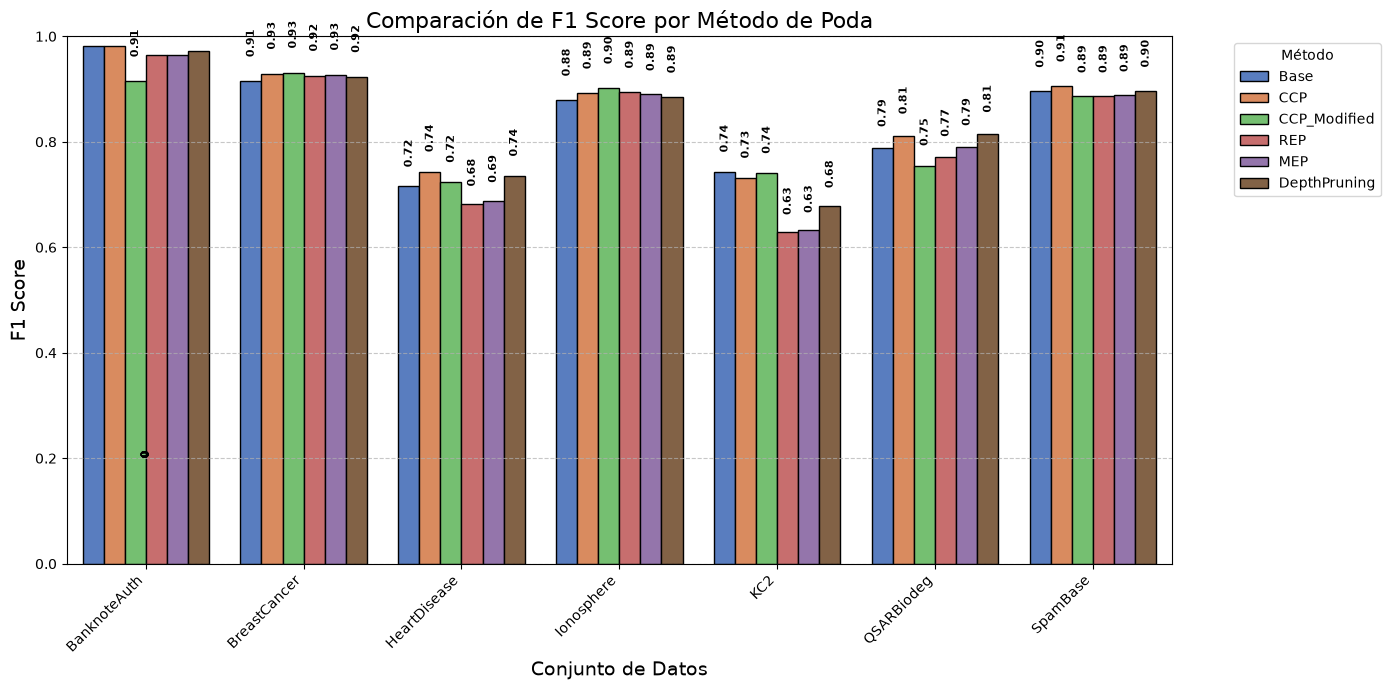

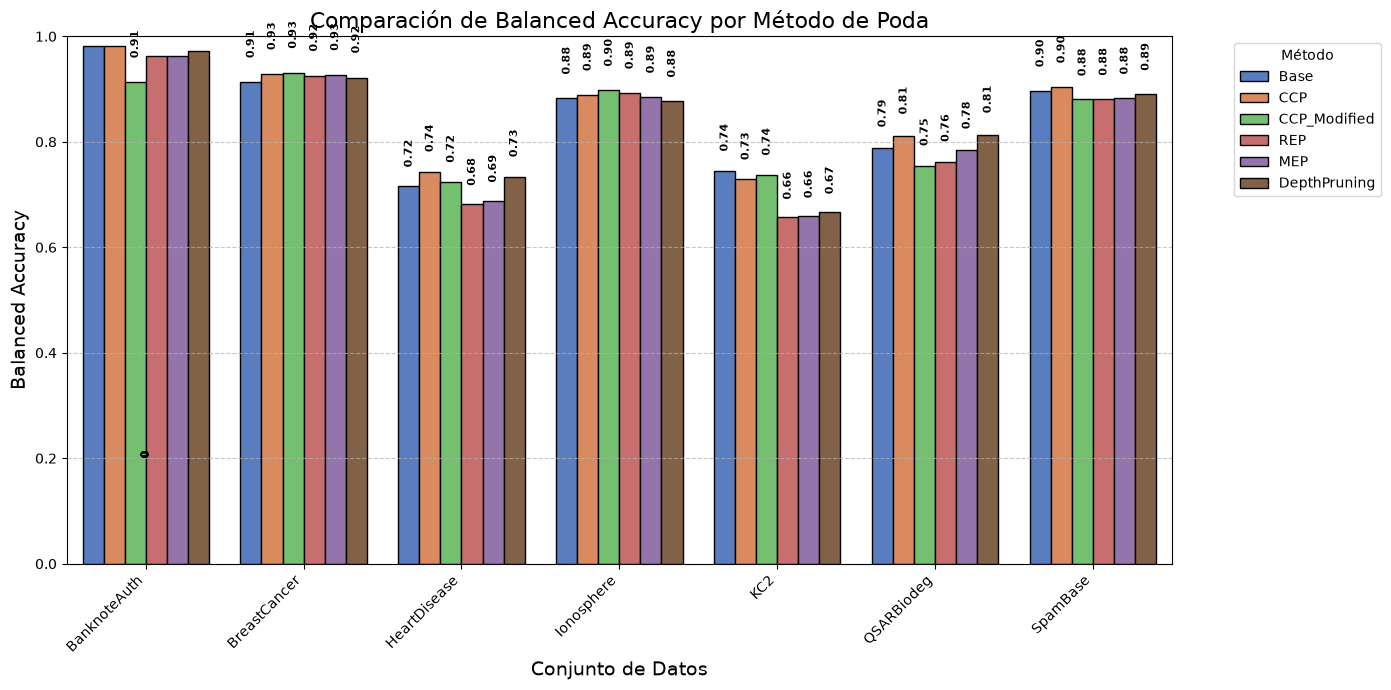

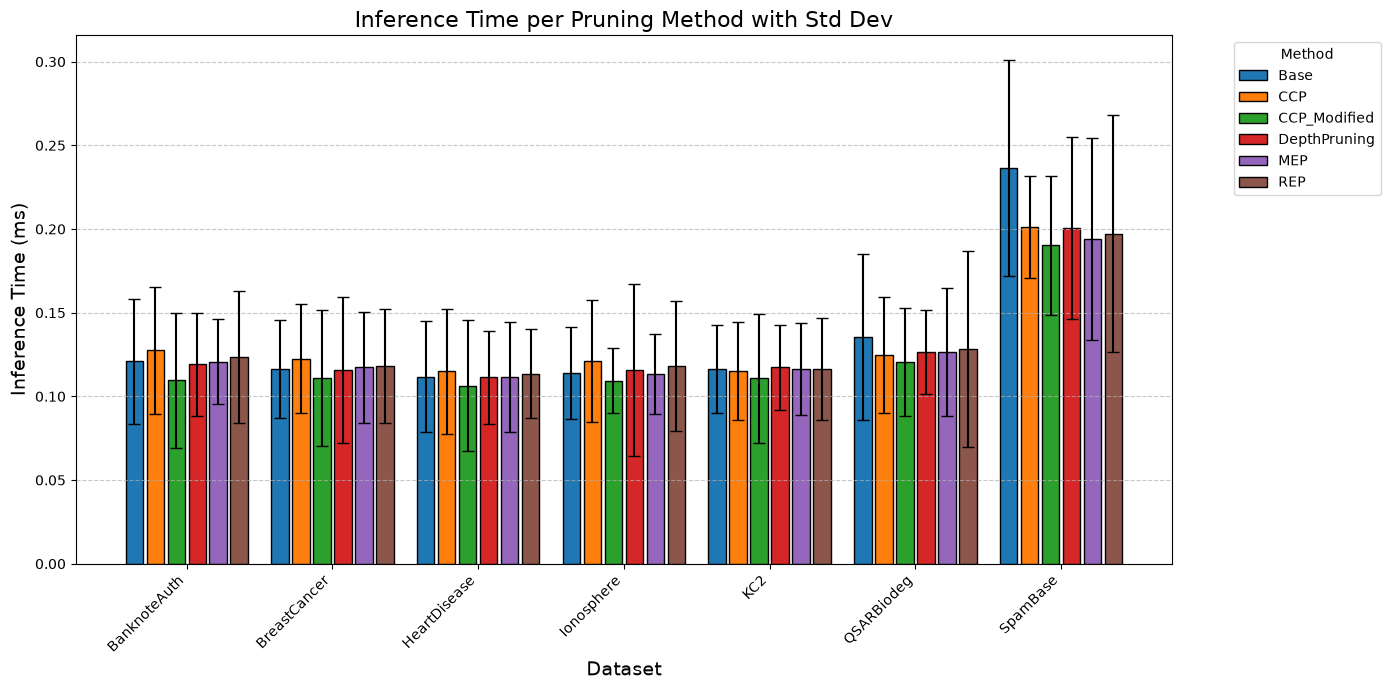

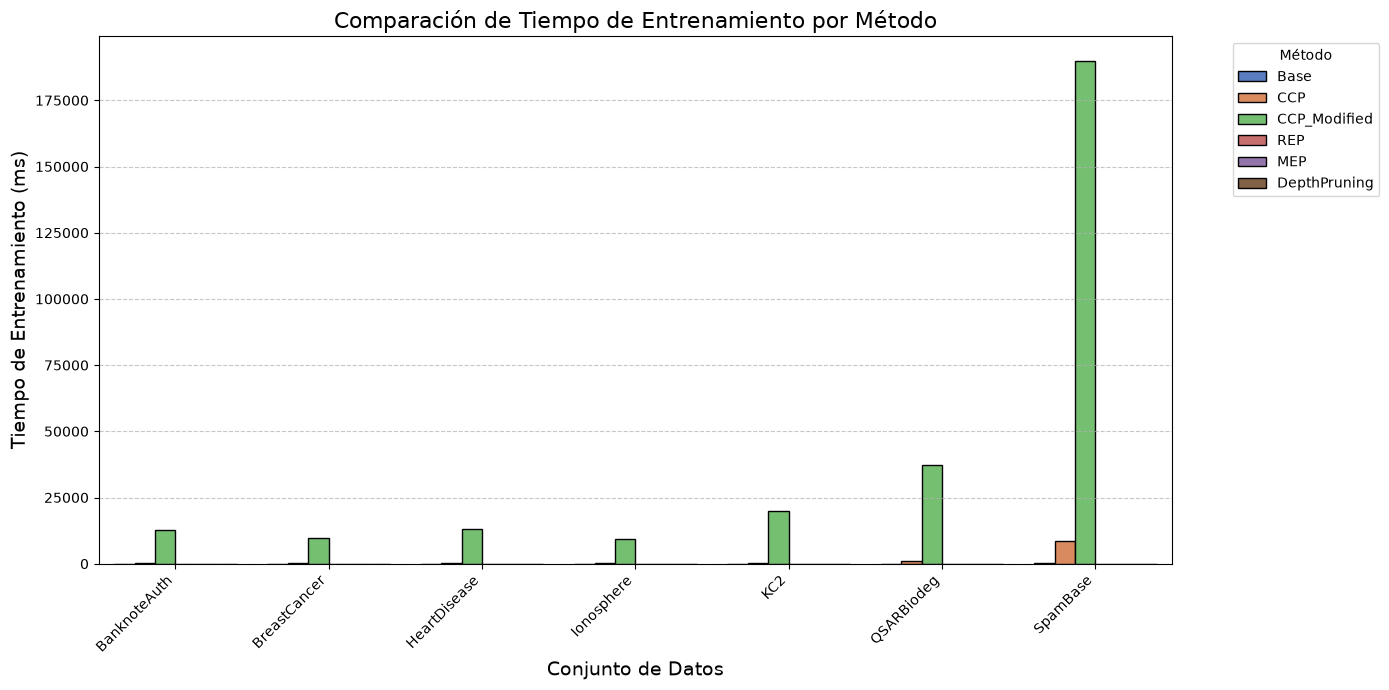

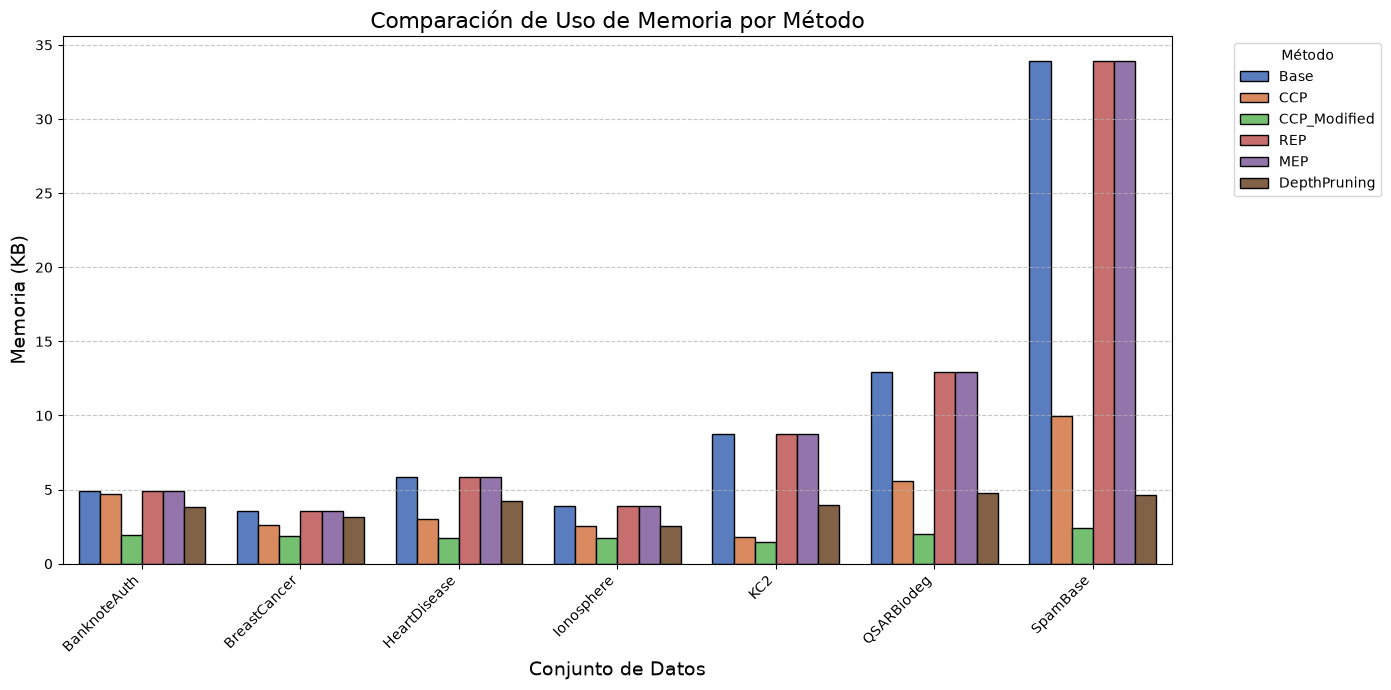

In [ ]:
# Gráfica de barras para F1 Score
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="F1_Score", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de F1 Score por Método de Poda", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# Gráfica de barras para Balanced Accuracy
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Balanced_Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Balanced Accuracy por Método de Poda", fontsize=16)
plt.ylabel("Balanced Accuracy", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()




# Compute average and std per group
grouped = metrics_df.groupby(["Dataset", "Method"], as_index=False).mean()

# Create the bar plot with error bars
plt.figure(figsize=(14, 7))

# Get unique methods and datasets
methods = grouped["Method"].unique()
datasets = grouped["Dataset"].unique()

# Create position indices for grouped bars
x = np.arange(len(datasets))
width = 0.12  # width of each bar
offsets = np.linspace(-width*len(methods)/2, width*len(methods)/2, len(methods))

for i, method in enumerate(methods):
    subset = grouped[grouped["Method"] == method]
    y = subset["Inference_Time_ms"].values
    yerr = subset["Inference_Time_Std_ms"].values
    plt.bar(x + offsets[i], y, width, label=method, yerr=yerr, capsize=4, edgecolor="black")

plt.xticks(x, datasets, rotation=45, ha="right")
plt.title("Inference Time per Pruning Method with Std Dev", fontsize=16)
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Tiempo de Entrenamiento ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Tiempo de Entrenamiento por Método", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Uso de Memoria ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Uso de Memoria por Método", fontsize=16)
plt.ylabel("Memoria (KB)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


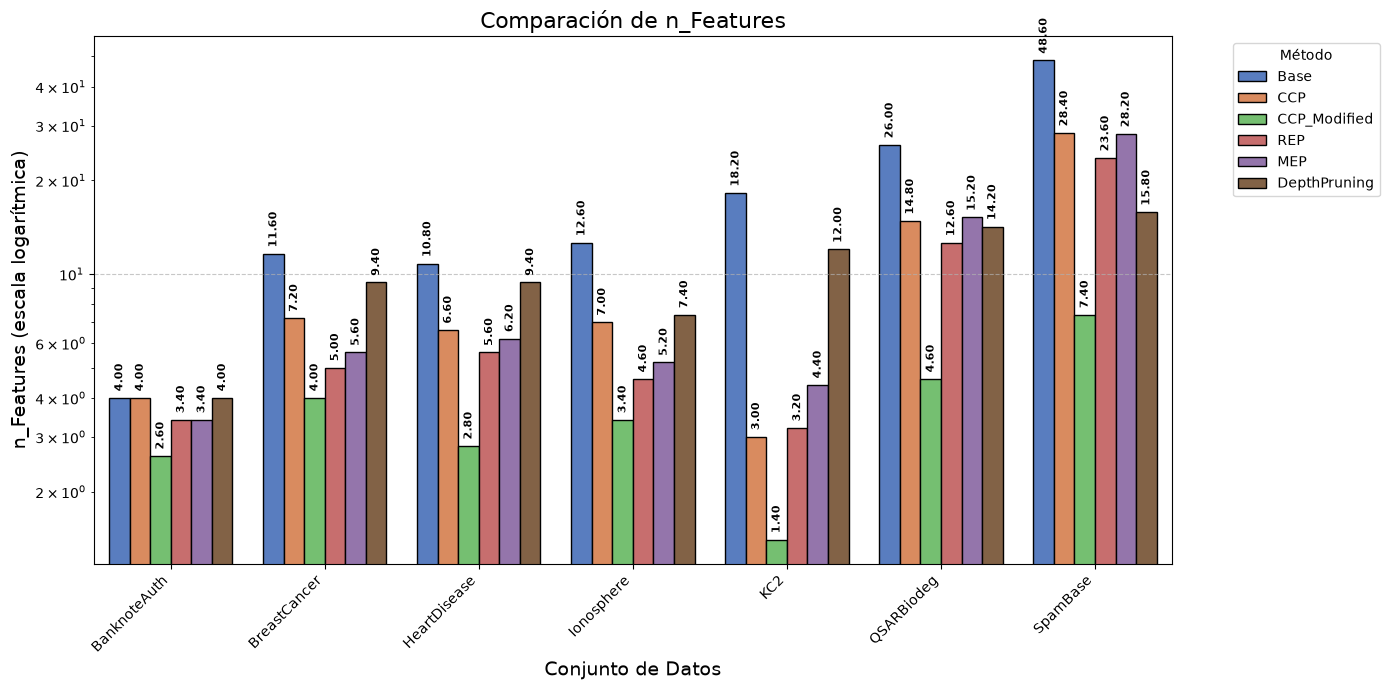

In [ ]:
# === Gráfica 5: n_Features ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="n_Features", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de n_Features", fontsize=16)
plt.ylabel("n_Features (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()